# Matrice de corrélation groupée par secteur (univers S&P 500)

Ce notebook construit la matrice de corrélation des rendements journaliers de 26 titres de l'univers S&P 500, **groupés par secteur**, pour la Phase 0 du rapport.

Objectif : montrer que les rendements s'organisent en **blocs sectoriels** (forte corrélation intra-secteur, plus faible entre secteurs), ce qui justifie de screener les paires cointégrées **à l'intérieur des secteurs** — et de situer la paire retenue ADI/MPWR dans le bloc des semi-conducteurs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cours ajustés de l'univers 215 titres (produit par 08a_bis)
adj = pd.read_csv("../data/sp500full_adj_close.csv", index_col=0, parse_dates=True)
log_ret = np.log(adj).diff().dropna()
print("Univers :", adj.shape[1], "titres |", adj.index.min().date(), "->", adj.index.max().date())

Univers : 215 titres | 2011-11-17 -> 2026-08-12


## 1. Sélection des titres, groupés par secteur

On choisit 26 titres répartis sur 7 secteurs. Les 8 titres de l'univers momentum (NVDA, AAPL, MSFT, AMZN, JPM, XOM, JNJ, PG) y figurent, complétés par d'autres du même secteur, plus la paire retenue ADI/MPWR. L'ordre des colonnes suit les secteurs pour que les blocs apparaissent visuellement.

In [2]:
groups = [
    ("Semi-cond.",  ["NVDA", "ADI", "MPWR", "AMAT", "NXPI", "AMD"]),
    ("Tech",        ["AAPL", "MSFT"]),
    ("Banques",     ["JPM", "BAC", "GS", "WFC", "MS"]),
    ("Énergie",     ["XOM", "CVX", "COP"]),
    ("Santé",       ["JNJ", "PFE", "MRK"]),
    ("Conso base",  ["PG", "KO", "PEP", "CL"]),
    ("Conso disc.", ["AMZN", "HD", "MCD"]),
]

# on ne garde que les titres réellement présents dans l'univers
groups = [(g, [t for t in ts if t in adj.columns]) for g, ts in groups]
order = [t for _, ts in groups for t in ts]
C = log_ret[order].corr()
print(f"{len(order)} titres retenus sur {len(groups)} secteurs")

26 titres retenus sur 7 secteurs


## 2. Corrélations moyennes intra- et inter-secteurs

On résume la structure : la corrélation moyenne **à l'intérieur** de chaque secteur (hors diagonale) et **entre** quelques paires de secteurs.

In [3]:
idx = {g: ts for g, ts in groups}

def block_mean(a, b):
    v = C.loc[a, b].values
    if a is b:  # même bloc : moyenne du triangle supérieur (hors diagonale)
        return v[np.triu_indices_from(v, 1)].mean()
    return v.mean()

print("Corrélation moyenne INTRA-secteur :")
for g, ts in groups:
    if len(ts) > 1:
        print(f"  {g:12s}: {block_mean(ts, ts):.2f}")

print("\nCorrélations INTER-secteurs (moyennes de bloc) :")
for a, b in [("Semi-cond.", "Tech"), ("Banques", "Énergie"),
             ("Conso base", "Santé"), ("Semi-cond.", "Banques"),
             ("Conso base", "Conso disc.")]:
    print(f"  {a} <-> {b:12s}: {block_mean(idx[a], idx[b]):.2f}")

print(f"\nADI <-> MPWR : {C.loc['ADI', 'MPWR']:.2f}")

Corrélation moyenne INTRA-secteur :
  Semi-cond.  : 0.60
  Tech        : 0.54
  Banques     : 0.79
  Énergie     : 0.81
  Santé       : 0.50
  Conso base  : 0.65
  Conso disc. : 0.36

Corrélations INTER-secteurs (moyennes de bloc) :
  Semi-cond. <-> Tech        : 0.46
  Banques <-> Énergie     : 0.49
  Conso base <-> Santé       : 0.42
  Semi-cond. <-> Banques     : 0.41
  Conso base <-> Conso disc. : 0.36

ADI <-> MPWR : 0.71


## 3. La figure : heatmap groupée par secteur

Chaque case affiche la corrélation ; des traits noirs séparent les secteurs, dont le nom est écrit en marge. Les blocs rouges sur la diagonale sont l'information à retenir.

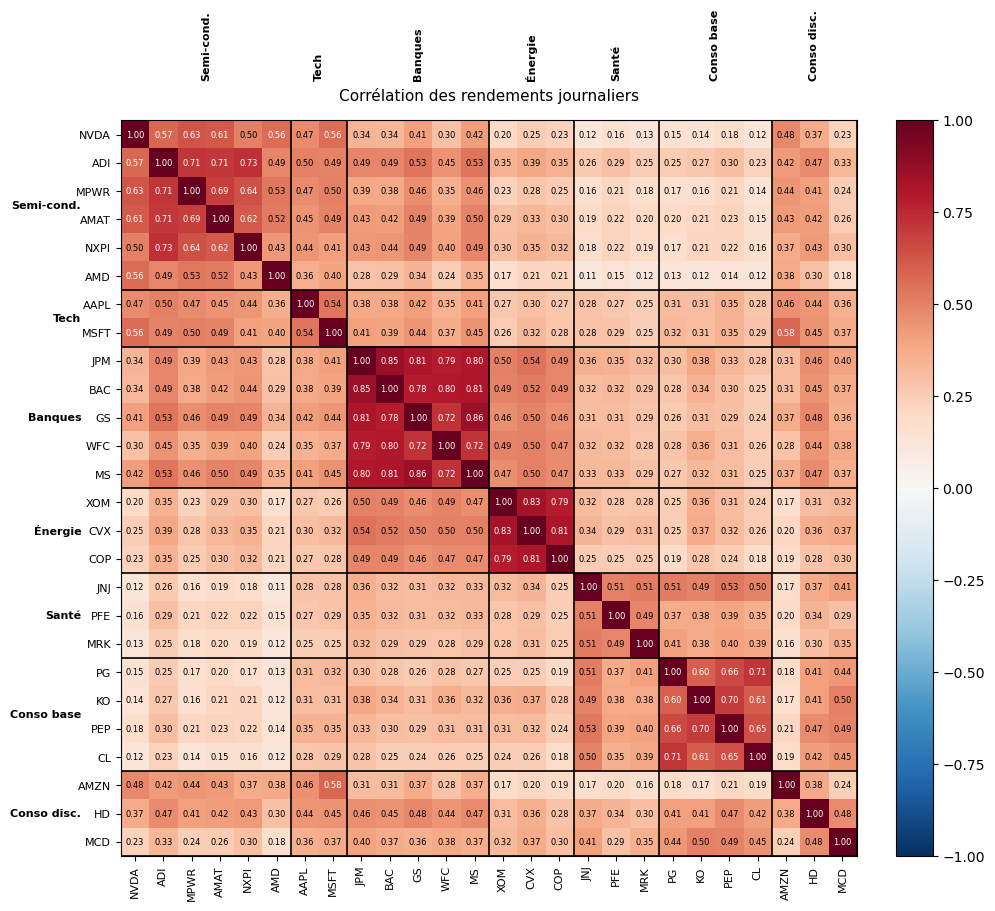

In [4]:
fig, ax = plt.subplots(figsize=(11, 9.2))
im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
n = len(order)
ax.set_xticks(range(n)); ax.set_xticklabels(order, rotation=90, fontsize=8)
ax.set_yticks(range(n)); ax.set_yticklabels(order, fontsize=8)

# valeurs dans les cases
for i in range(n):
    for j in range(n):
        v = C.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6,
                color="white" if abs(v) > 0.55 else "black")

# séparateurs + étiquettes de secteur
pos = 0
for g, ts in groups:
    s, e = pos, pos + len(ts)
    ax.axhline(s - 0.5, color="k", lw=1.2); ax.axvline(s - 0.5, color="k", lw=1.2)
    ax.text(-1.9, (s + e - 1) / 2, g, ha="right", va="center",
            fontsize=8, fontweight="bold")
    ax.text((s + e - 1) / 2, -1.9, g, ha="center", va="bottom",
            fontsize=8, fontweight="bold", rotation=90)
    pos = e
ax.axhline(n - 0.5, color="k", lw=1.2); ax.axvline(n - 0.5, color="k", lw=1.2)

ax.set_title("Corrélation des rendements journaliers",
             fontsize=11, pad=14)
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("../data/correlation_sectors.png", dpi=130)  # optionnel : sauvegarde
plt.show()

## Ce qu'on retient

- Les rendements s'organisent en **blocs sectoriels** : corrélation moyenne intra-secteur de 0,50 à 0,81, contre 0,36–0,49 entre secteurs.
- Les secteurs les plus soudés sont l'**énergie** et les **banques** (ils tradent presque comme un seul actif) ; la **consommation discrétionnaire** est la plus éclatée.
- La forte corrélation **intra-secteur** justifie de chercher les paires cointégrées **dans** les secteurs. C'est là que se trouve ADI/MPWR (0,71), dans le bloc des semi-conducteurs — condition nécessaire que la cointégration viendra compléter.